In [1]:
import sys; sys.path.insert(0, "..")
import matplotlib.pyplot as plt
from src.data.align import align, gap_report, busiest_day

H5 = "../data/raw/ukdale.h5"

In [2]:
start, end = busiest_day(H5, 1, "kettle")
print(start.date())

2012-12-25


In [3]:
df = align(H5, 1, "kettle", start=start, end=end)
print(df.shape)
gap_report(df)

(14400, 2)


,missing_pct,longest_gap_min
mains,4.83,69.6
kettle,4.83,69.6


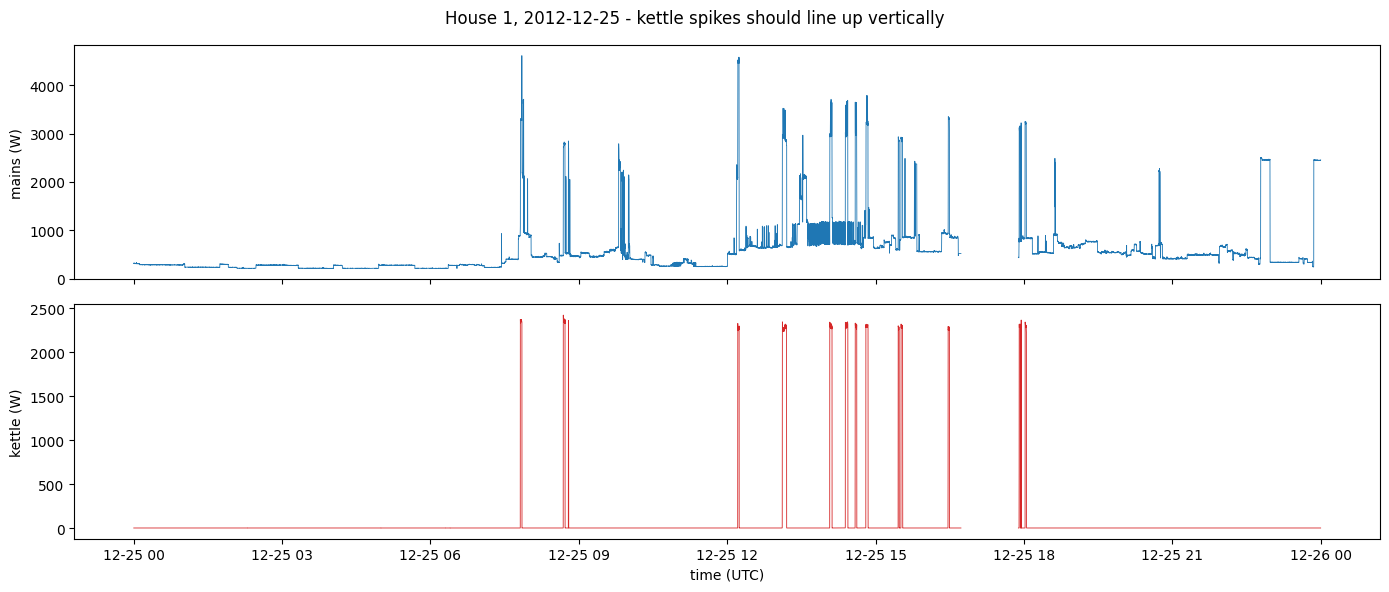

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax[0].plot(df.index, df["mains"], lw=0.6)
ax[0].set_ylabel("mains (W)")

ax[1].plot(df.index, df["kettle"], lw=0.6, color="tab:red")
ax[1].set_ylabel("kettle (W)")
ax[1].set_xlabel("time (UTC)")

fig.suptitle(f"House 1, {start.date()} - kettle spikes should line up vertically")
plt.tight_layout()